# Random Forest Confidence Classification

RandomForestClassifier로 confidence 1~5 class를 직접 예측합니다. XGBoost classification 노트북과 같은 전처리, split, feature set, 평가지표, loss curve, confusion matrix 저장 구조를 사용합니다.

In [1]:
from pathlib import Path
import os
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, mean_absolute_error, log_loss
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / 'data').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = ROOT / 'data'
META_PATH = DATA_DIR / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_DIR = DATA_DIR / 'features' / 'clap_audio_embeddings'
TEXT_DIR = DATA_DIR / 'features' / 'clap_text_embeddings'

print('root:', ROOT)
print('metadata:', META_PATH)


root: c:\Users\solok\Desktop\Dcase baseline
metadata: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv


In [2]:
def clean_metadata(df):
    df = df.copy()
    df['sound_id'] = df['sound_id'].astype(str).str.strip()
    df['class'] = df['class'].astype(str).str.strip()
    if 'class_idx' in df.columns:
        class_idx = df['class_idx'].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith('99') | class_idx.str.endswith('00')))
        df = df[keep].copy()
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
    df = df[df['confidence'].isin([1, 2, 3, 4, 5])].copy()
    df['confidence'] = df['confidence'].astype(int)
    return df.reset_index(drop=True)


def one_hot(values, categories):
    index = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        col_idx = index.get(str(value))
        if col_idx is not None:
            arr[row_idx, col_idx] = 1.0
    return arr


def finite_float32(x):
    return np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def load_embeddings(df, audio_dir, text_dir):
    audio_rows, text_rows, kept = [], [], []
    for idx, row in df.reset_index(drop=True).iterrows():
        sound_id = str(row['sound_id'])
        audio_path = audio_dir / f'{sound_id}.npy'
        text_path = text_dir / f'{sound_id}.npy'
        if audio_path.is_file() and text_path.is_file():
            audio_rows.append(finite_float32(np.load(audio_path).reshape(-1)))
            text_rows.append(finite_float32(np.load(text_path).reshape(-1)))
            kept.append(idx)
    kept_df = df.reset_index(drop=True).iloc[kept].reset_index(drop=True).copy()
    return kept_df, finite_float32(np.vstack(audio_rows)), finite_float32(np.vstack(text_rows))


def build_feature_sets():
    meta = clean_metadata(pd.read_csv(META_PATH))
    categories = sorted(meta['class'].astype(str).unique().tolist())
    df, audio, text = load_embeddings(meta, AUDIO_DIR, TEXT_DIR)
    class_oh = one_hot(df['class'].astype(str).tolist(), categories)
    desc = df['description'] if 'description' in df.columns else pd.Series([''] * len(df))
    desc_len = desc.fillna('').astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)

    x_method1 = finite_float32(np.concatenate([text, audio, class_oh], axis=1))
    x_method2 = finite_float32(np.concatenate([text, audio, class_oh, desc_len], axis=1))
    y = df['confidence'].to_numpy(dtype=np.int64)
    feature_sets = {
        'method1_text_audio_label': x_method1,
        'method2_text_audio_label_desc_len': x_method2,
    }
    return df, feature_sets, y, categories


def make_splits(y):
    idx = np.arange(len(y))
    train_idx, temp_idx = train_test_split(idx, test_size=0.40, random_state=SEED, stratify=y)
    valid_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx])
    return train_idx, valid_idx, test_idx


def compute_metrics(y_true, y_pred_class, y_score_for_mae=None):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_class, average='macro', zero_division=0)
    mae_source = y_pred_class if y_score_for_mae is None else y_score_for_mae
    return {
        'accuracy': float(accuracy_score(y_true, y_pred_class)),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'mae': float(mean_absolute_error(y_true, mae_source)),
    }


def save_confusion(y_true, y_pred, title, out_path):
    labels = [1, 2, 3, 4, 5]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted confidence')
    ax.set_ylabel('True confidence')
    ax.set_xticks(range(5), labels)
    ax.set_yticks(range(5), labels)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_norm[i, j] * 100:.1f}%', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)
    return cm, cm_norm


def save_loss_curve(history_df, metric_name, title, out_path):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history_df['n_estimators'], history_df[f'train_{metric_name}'], label=f'train {metric_name}')
    ax.plot(history_df['n_estimators'], history_df[f'validation_{metric_name}'], label=f'validation {metric_name}')
    ax.set_title(title)
    ax.set_xlabel('Number of trees')
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


## 학습 설정

RandomForest는 XGBoost처럼 boosting round별 eval loss를 자동으로 제공하지 않으므로 `warm_start=True`로 tree 수를 늘려가며 train/validation `mlogloss`를 계산합니다. 최종 모델은 validation `mlogloss`가 가장 낮은 tree 수로 다시 학습합니다.

In [3]:
OUTPUT_DIR = ROOT / 'outputs' / 'random_forest_confidence_classification'
REPORT_DIR = OUTPUT_DIR / 'reports'
PLOT_DIR = OUTPUT_DIR / 'plots'
PRED_DIR = OUTPUT_DIR / 'predictions'
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TREE_GRID = list(range(50, 801, 50))
LABELS = [1, 2, 3, 4, 5]


def make_classifier(n_estimators=100, warm_start=False):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        class_weight=None,
        random_state=SEED,
        n_jobs=-1,
        warm_start=warm_start,
    )


def probability_for_labels(model, x, labels=LABELS):
    raw = model.predict_proba(x)
    aligned = np.zeros((len(x), len(labels)), dtype=np.float64)
    class_to_col = {int(cls): idx for idx, cls in enumerate(model.classes_)}
    for out_col, label in enumerate(labels):
        in_col = class_to_col.get(label)
        if in_col is not None:
            aligned[:, out_col] = raw[:, in_col]
    return aligned


def fit_classifier_with_history(x_train, y_train, x_valid, y_valid):
    model = make_classifier(n_estimators=0, warm_start=True)
    rows = []
    for n_estimators in TREE_GRID:
        model.set_params(n_estimators=n_estimators)
        model.fit(x_train, y_train)
        train_proba = probability_for_labels(model, x_train)
        valid_proba = probability_for_labels(model, x_valid)
        rows.append({
            'n_estimators': n_estimators,
            'train_mlogloss': float(log_loss(y_train, train_proba, labels=LABELS)),
            'validation_mlogloss': float(log_loss(y_valid, valid_proba, labels=LABELS)),
        })
        print(f'n_estimators={n_estimators} validation_mlogloss={rows[-1]["validation_mlogloss"]:.6f}')
    history = pd.DataFrame(rows)
    best_n = int(history.loc[history['validation_mlogloss'].idxmin(), 'n_estimators'])
    final_model = make_classifier(n_estimators=best_n, warm_start=False)
    final_model.fit(x_train, y_train)
    return final_model, history, best_n


df, feature_sets, y, categories = build_feature_sets()
train_idx, valid_idx, test_idx = make_splits(y)

print('samples:', len(df))
print('split:', len(train_idx), len(valid_idx), len(test_idx))
print('class categories:', len(categories))
display(pd.Series(y).value_counts().sort_index().rename('confidence_count'))

summary_rows = []
for feature_name, x in feature_sets.items():
    print(f'\n===== {feature_name} | dim={x.shape[1]} =====')
    y_train = y[train_idx]
    y_valid = y[valid_idx]
    y_test = y[test_idx]

    model, history, best_n = fit_classifier_with_history(x[train_idx], y_train, x[valid_idx], y_valid)

    pred_class = model.predict(x[test_idx]).astype(int)
    metrics = compute_metrics(y_test, pred_class)
    metrics.update({
        'feature_set': feature_name,
        'feature_dim': int(x.shape[1]),
        'model': 'RandomForestClassifier',
        'best_iteration': best_n,
    })
    summary_rows.append(metrics)

    history.to_csv(REPORT_DIR / f'{feature_name}_loss_history.csv', index=False)
    save_loss_curve(history, 'mlogloss', f'{feature_name} - RandomForestClassifier mlogloss', PLOT_DIR / f'{feature_name}_train_valid_mlogloss.png')
    cm, cm_norm = save_confusion(y_test, pred_class, f'{feature_name} - row-normalized confusion', PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')
    pd.DataFrame(cm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_counts.csv')
    pd.DataFrame(cm_norm, index=[f'true_{i}' for i in range(1, 6)], columns=[f'pred_{i}' for i in range(1, 6)]).to_csv(REPORT_DIR / f'{feature_name}_confusion_row_normalized.csv')

    pred_out = df.iloc[test_idx][['sound_id', 'class', 'confidence']].copy()
    pred_out['predicted_confidence'] = pred_class
    pred_out.to_csv(PRED_DIR / f'{feature_name}_test_predictions.csv', index=False)

summary = pd.DataFrame(summary_rows).sort_values(['macro_f1', 'accuracy'], ascending=[False, False])
summary.to_csv(REPORT_DIR / 'random_forest_classification_summary.csv', index=False)
display(summary)


samples: 10956
split: 6573 2191 2192
class categories: 23


1     106
2     749
3    3280
4    6045
5     776
Name: confidence_count, dtype: int64


===== method1_text_audio_label | dim=1047 =====
n_estimators=50 validation_mlogloss=1.176895
n_estimators=100 validation_mlogloss=1.055187
n_estimators=150 validation_mlogloss=1.007852
n_estimators=200 validation_mlogloss=0.980017
n_estimators=250 validation_mlogloss=0.977728
n_estimators=300 validation_mlogloss=0.977996
n_estimators=350 validation_mlogloss=0.977637
n_estimators=400 validation_mlogloss=0.977504
n_estimators=450 validation_mlogloss=0.964787
n_estimators=500 validation_mlogloss=0.964185
n_estimators=550 validation_mlogloss=0.963911
n_estimators=600 validation_mlogloss=0.964182
n_estimators=650 validation_mlogloss=0.963739
n_estimators=700 validation_mlogloss=0.964095
n_estimators=750 validation_mlogloss=0.964598
n_estimators=800 validation_mlogloss=0.963981

===== method2_text_audio_label_desc_len | dim=1048 =====
n_estimators=50 validation_mlogloss=1.184442
n_estimators=100 validation_mlogloss=1.017034
n_estimators=150 validation_mlogloss=0.998404
n_estimators=200 vali

,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
1,0.584854,0.565364,0.284047,0.303751,0.484945,method2_text_audio_label_desc_len,1048,RandomForestClassifier,650
0,0.584398,0.580926,0.283463,0.303450,0.488595,method1_text_audio_label,1047,RandomForestClassifier,650


## 결과 확인

저장된 train/validation loss curve와 row-normalized confusion matrix를 표시합니다.

,accuracy,macro_precision,macro_recall,macro_f1,mae,feature_set,feature_dim,model,best_iteration
0,0.584854,0.565364,0.284047,0.303751,0.484945,method2_text_audio_label_desc_len,1048,RandomForestClassifier,650
1,0.584398,0.580926,0.283463,0.303450,0.488595,method1_text_audio_label,1047,RandomForestClassifier,650


### method2_text_audio_label_desc_len

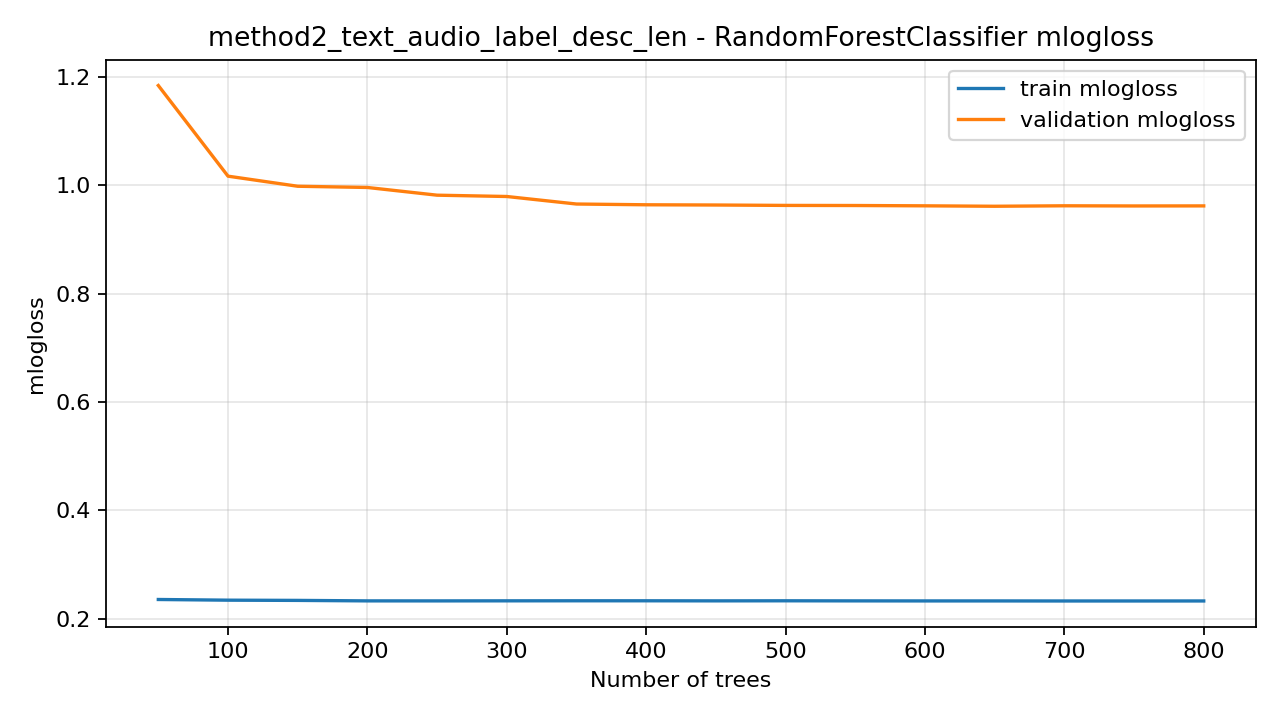

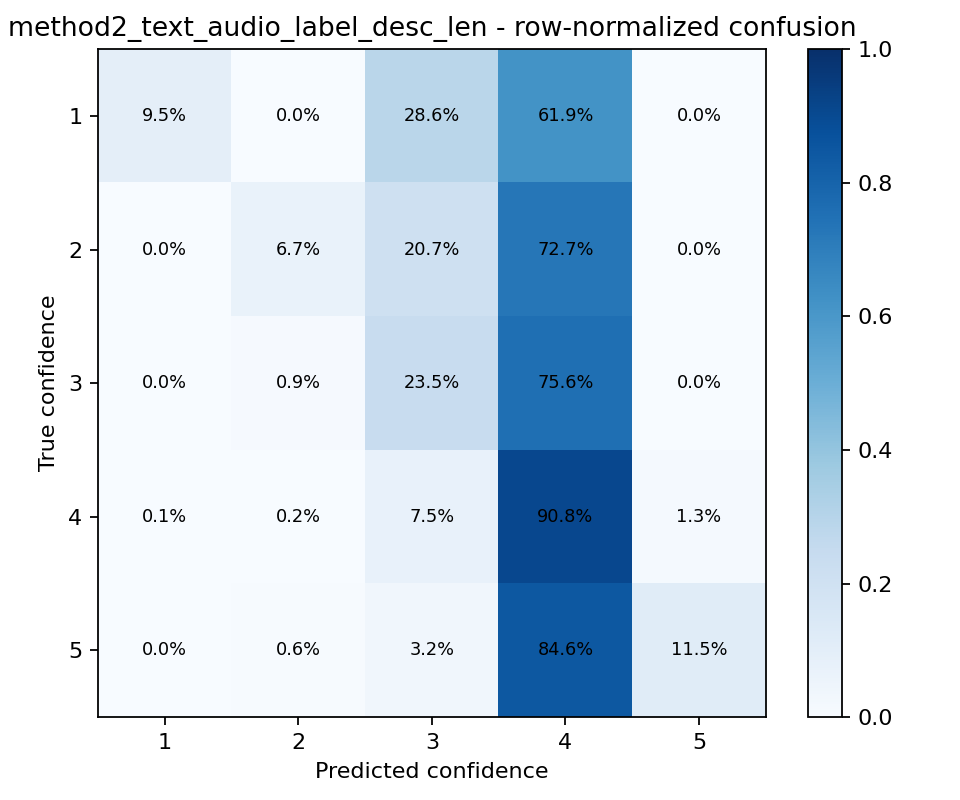

### method1_text_audio_label

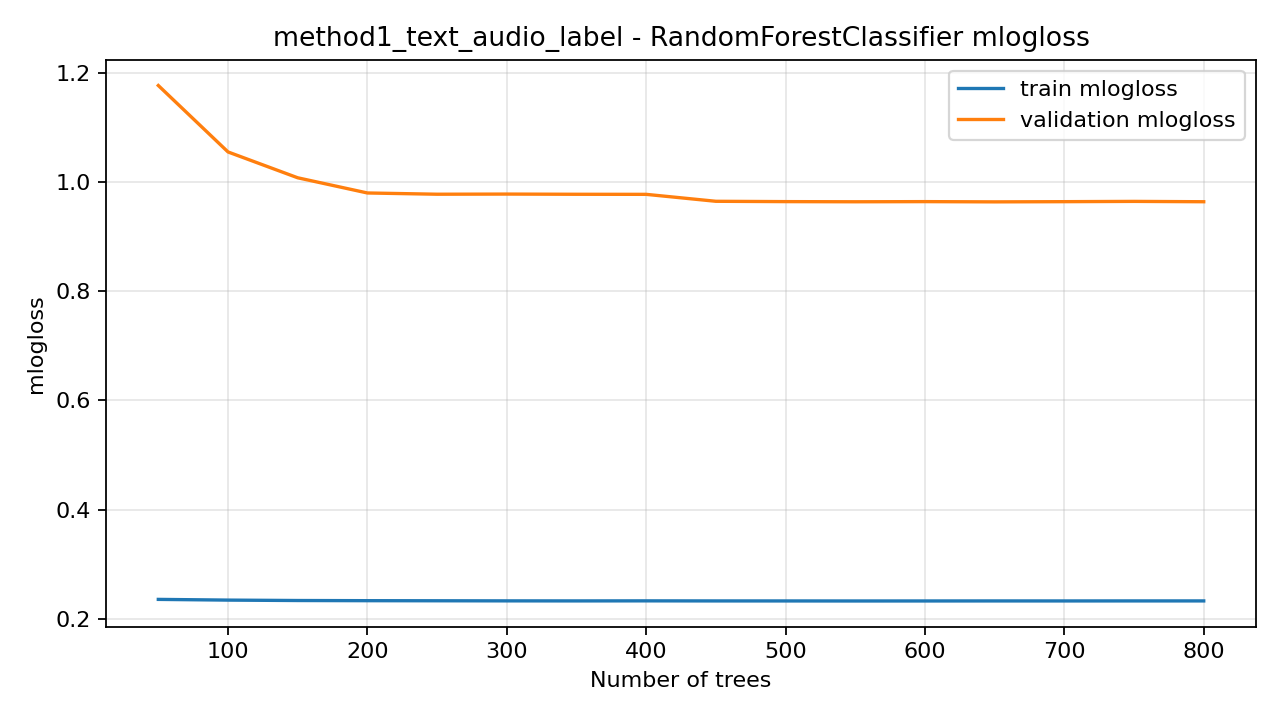

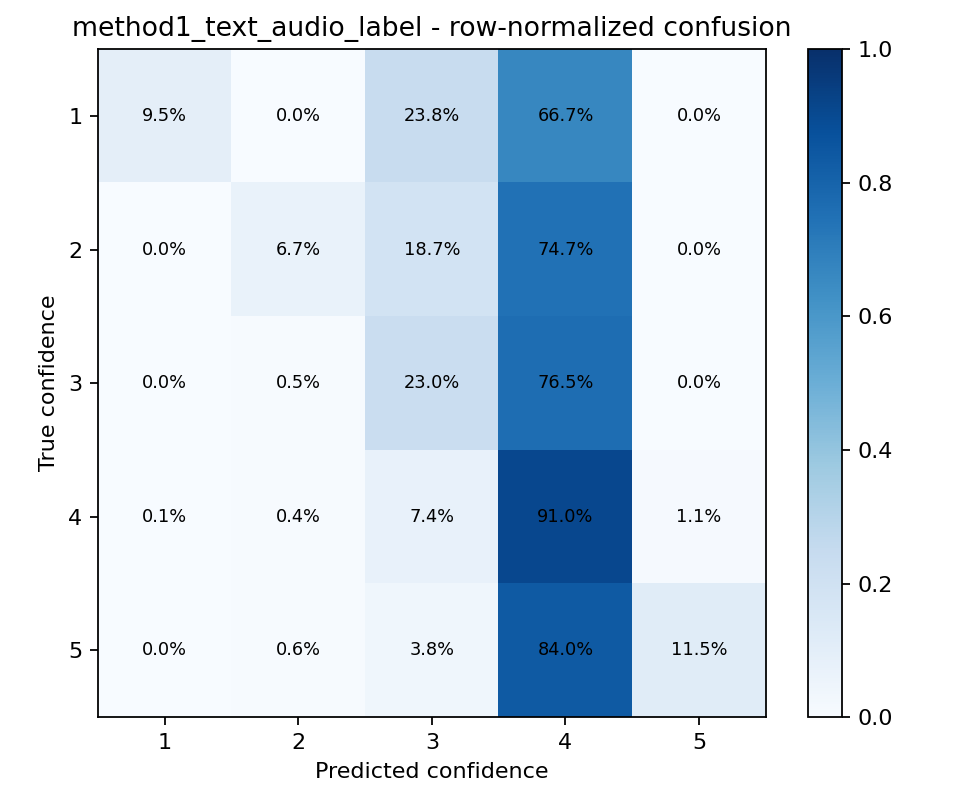

In [4]:
summary = pd.read_csv(REPORT_DIR / 'random_forest_classification_summary.csv')
display(summary)
for feature_name in summary['feature_set']:
    display(Markdown(f'### {feature_name}'))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_train_valid_mlogloss.png')))
    display(Image(filename=str(PLOT_DIR / f'{feature_name}_confusion_row_normalized.png')))
